In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
data = pd.read_csv('D:\\data repository\\student.csv')

In [3]:
data

,Math,Reading,Writing
0,48,68,63
1,62,81,72
2,79,80,78
3,76,83,79
4,59,64,62
...,...,...,...
995,72,74,70
996,73,86,90
997,89,87,94
998,83,82,78


<Axes: xlabel='Math', ylabel='Reading'>

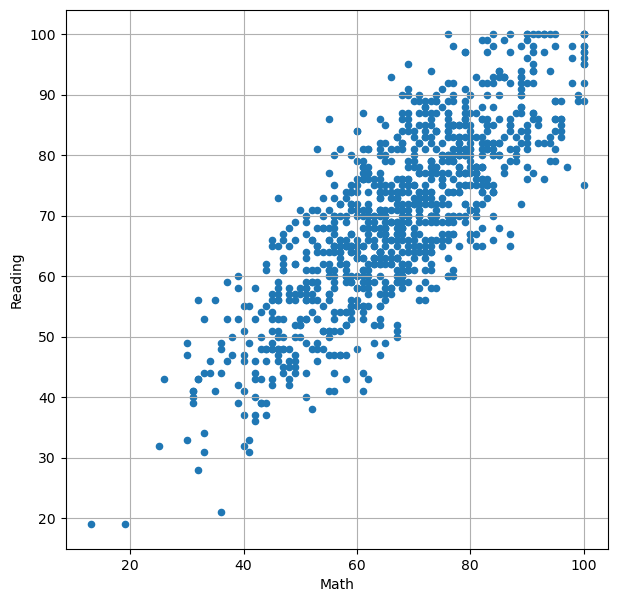

In [4]:
data.plot(kind='scatter',
         x='Math',
         y='Reading',
         figsize=(7,7),
         xlabel='Math',
         ylabel='Reading',
         grid=True)

<Axes: xlabel='Math', ylabel='Writing'>

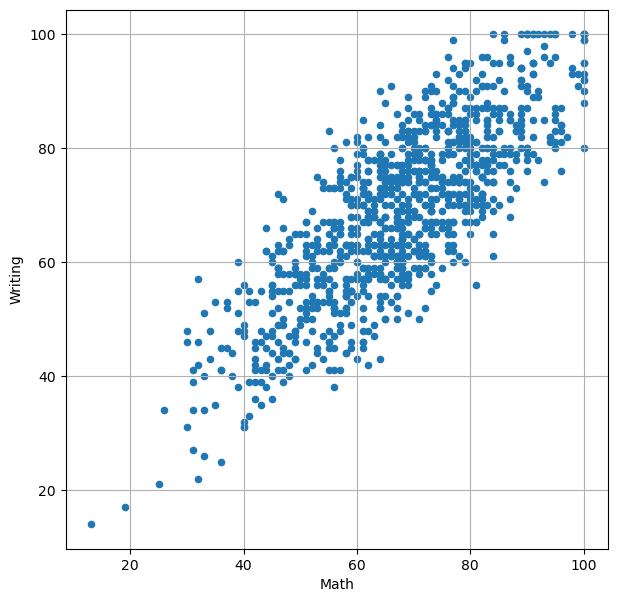

In [5]:
data.plot(kind='scatter',
         x='Math',
         y='Writing',
         figsize=(7,7),
         xlabel='Math',
         ylabel='Writing',
         grid=True)

<Axes: xlabel='Reading', ylabel='Writing'>

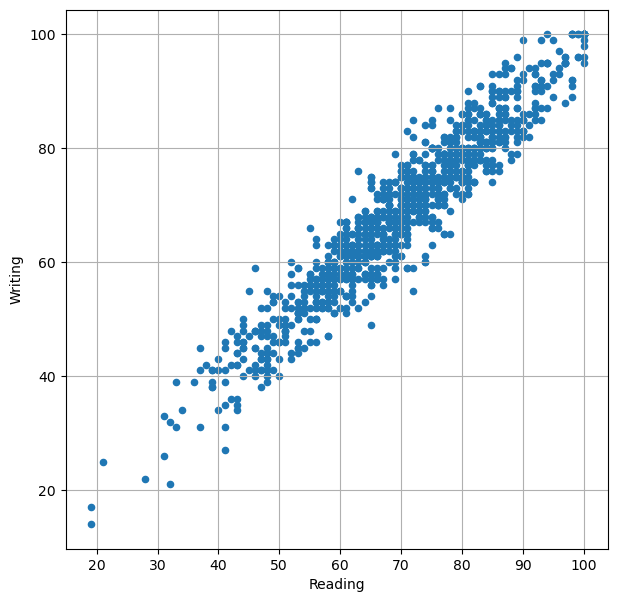

In [6]:
data.plot(kind='scatter',
         x='Reading',
         y='Writing',
         figsize=(7,7),
         xlabel='Reading',
         ylabel='Writing',
         grid=True)

In [7]:
stats.pearsonr(data['Math'], data['Reading'])

PearsonRResult(statistic=0.8064691486784779, pvalue=5.523856100185249e-230)

In [8]:
stats.pearsonr(data['Math'],data['Writing'])

PearsonRResult(statistic=0.8011595965718683, pvalue=9.38996811018274e-225)

In [9]:
stats.pearsonr(data['Reading'],data['Writing'])

PearsonRResult(statistic=0.9522256981148806, pvalue=0.0)

In [10]:
import seaborn as sns

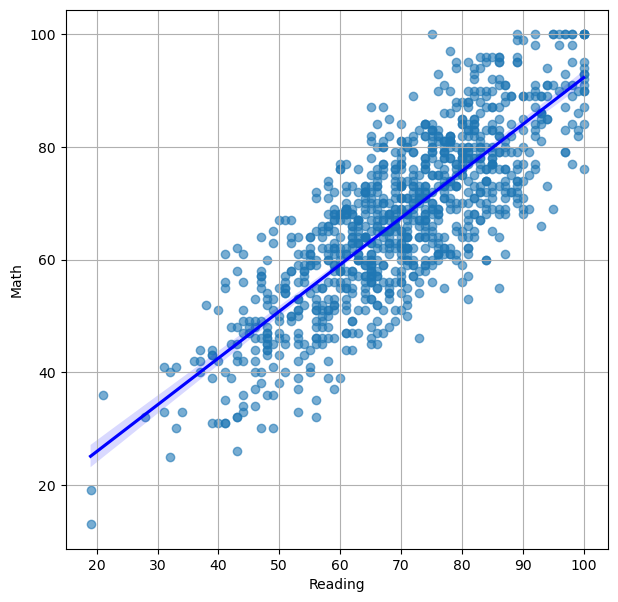

In [11]:
plt.figure(figsize=(7,7))
sns.regplot(x='Reading',y='Math',data=data,scatter_kws={'alpha':0.6},
           line_kws={'color':'blue'})
plt.xlabel('Reading')
plt.ylabel('Math')
plt.grid()
plt.show()

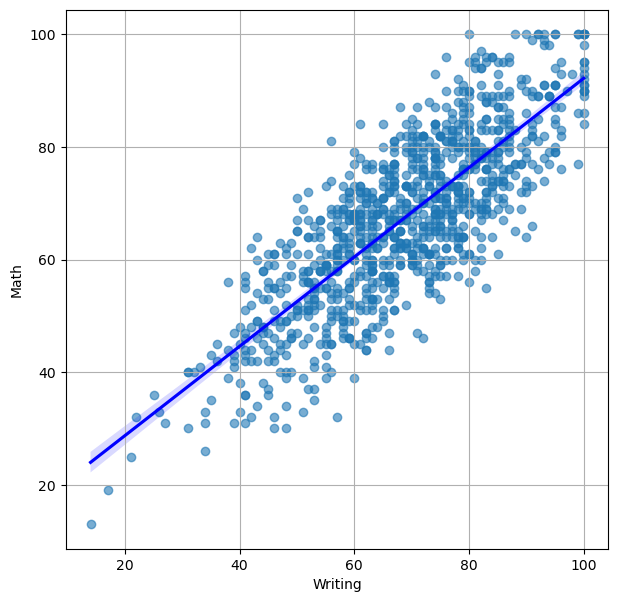

In [12]:
plt.figure(figsize=(7,7))
sns.regplot(x='Writing',y='Math',data=data,scatter_kws={'alpha':0.6},
           line_kws={'color':'blue'})
plt.xlabel('Writing')
plt.ylabel('Math')
plt.grid()
plt.show()

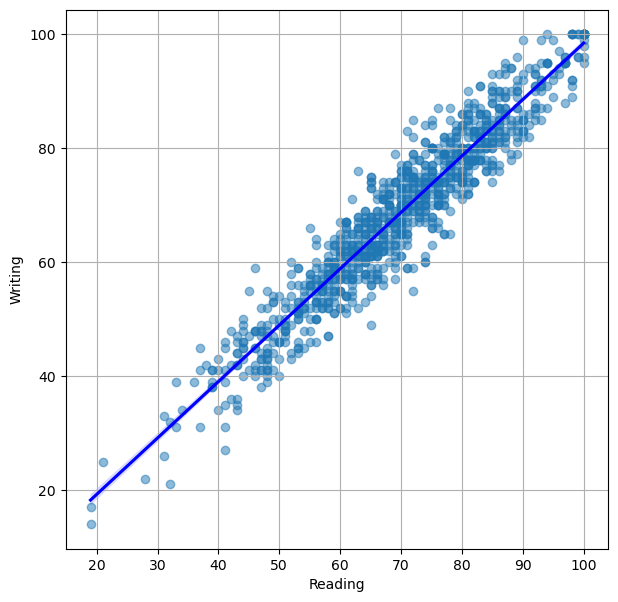

In [13]:
plt.figure(figsize=(7,7))
sns.regplot(x='Reading',y='Writing',data=data,scatter_kws={'alpha':0.5},line_kws={'color':'blue'})
plt.grid()
plt.show()

In [28]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [19]:
x= data[['Reading','Writing']]

x_with_const = sm.add_constant(x)

vif_output = pd.DataFrame()
vif_output['variables'] = x_with_const.columns
vif_output['coefficients'] = [variance_inflation_factor(x_with_const.values,i) for i in range(x_with_const.shape[1])]
print(vif_output.iloc[1:])

  variables  coefficients
1   Reading     10.721996
2   Writing     10.721996


In [38]:
data['Reading_Writing'] = np.ceil((data['Reading'] + data['Writing'])/2)

In [39]:
data

,Math,Reading,Writing,Reading_Writing
0,48,68,63,66.0
1,62,81,72,77.0
2,79,80,78,79.0
3,76,83,79,81.0
4,59,64,62,63.0
...,...,...,...,...
995,72,74,70,72.0
996,73,86,90,88.0
997,89,87,94,91.0
998,83,82,78,80.0


In [42]:
data['Math'].corr(data['Reading_Writing'])

0.8130767640177768

In [43]:
stats.pearsonr(data['Math'],data['Reading_Writing'])

PearsonRResult(statistic=0.813076764017777, pvalue=1.003631062004424e-236)

<Axes: xlabel='Reading_Writing', ylabel='Math'>

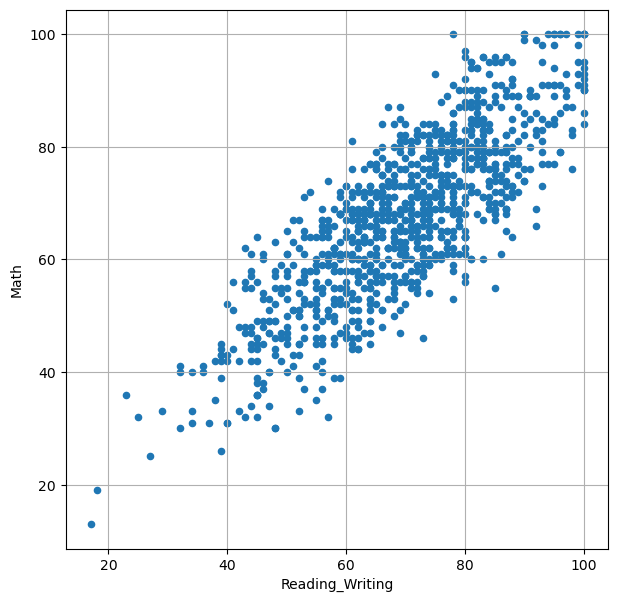

In [18]:
data.plot(kind='scatter',
         y='Math',
         x='Reading_Writing',
         figsize=(7,7),
         grid=True)

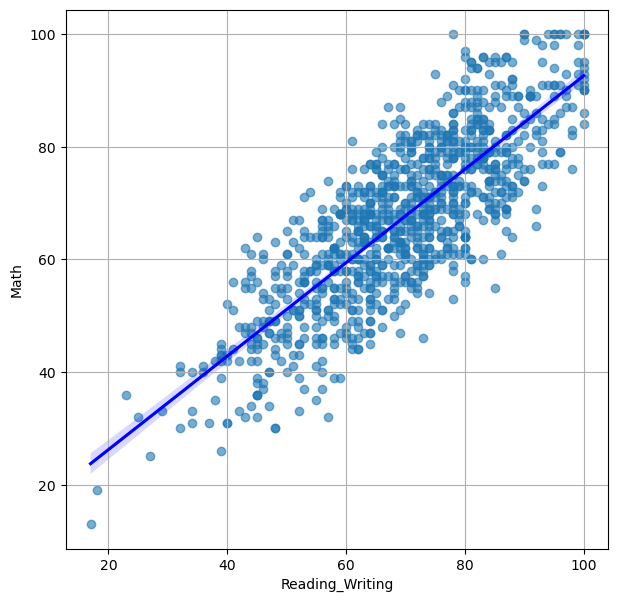

In [19]:
plt.figure(figsize=(7,7))
sns.regplot(x='Reading_Writing',y='Math',data=data,scatter_kws={'alpha':0.6},line_kws={'color':'blue'})
plt.grid()

In [20]:
import statsmodels.api as sm

In [21]:
x1 = sm.add_constant(data['Reading_Writing'])
y = data['Math']

model_mean = sm.OLS(y,x1).fit()

print(model_mean.summary())

                            OLS Regression Results                            
Dep. Variable:                   Math   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     1947.
Date:                Thu, 16 Jul 2026   Prob (F-statistic):          1.00e-236
Time:                        02:30:32   Log-Likelihood:                -3591.1
No. Observations:                1000   AIC:                             7186.
Df Residuals:                     998   BIC:                             7196.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.6160      1.336     

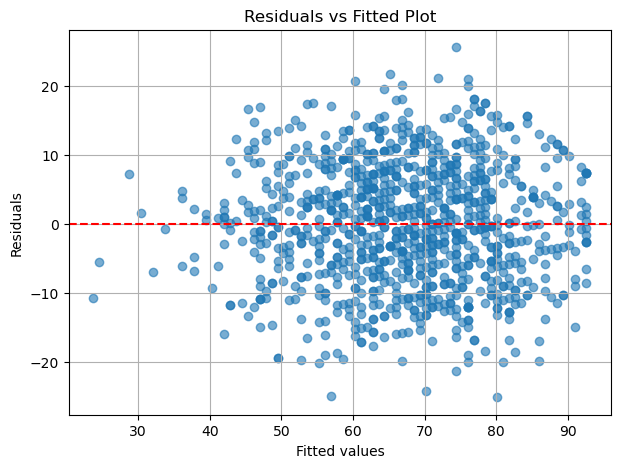

In [22]:
plt.figure(figsize=(7,5))
plt.scatter(model_mean.predict(x1), model_mean.resid,alpha=0.6 )
plt.axhline(y=0,color='red',linestyle='--')
plt.title('Residuals vs Fitted Plot')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid()
plt.show()

In [23]:
from statsmodels.stats.diagnostic import het_white

In [24]:
het_white(model_mean.resid, model_mean.model.exog)

(6.140079390204778,
 0.04641931220150865,
 3.0797394205604856,
 0.04640885082810302)

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

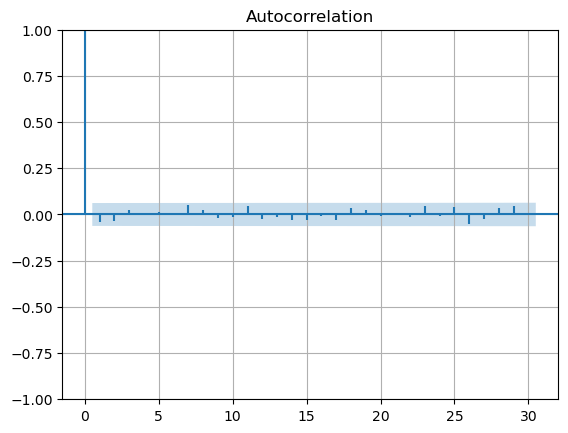

In [26]:
plot_acf(model_mean.resid, marker='')
plt.grid()

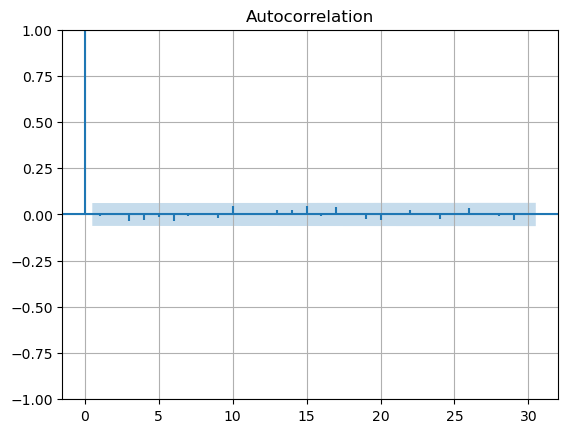

In [27]:
plot_acf(model_mean.resid**2, marker='')
plt.grid()

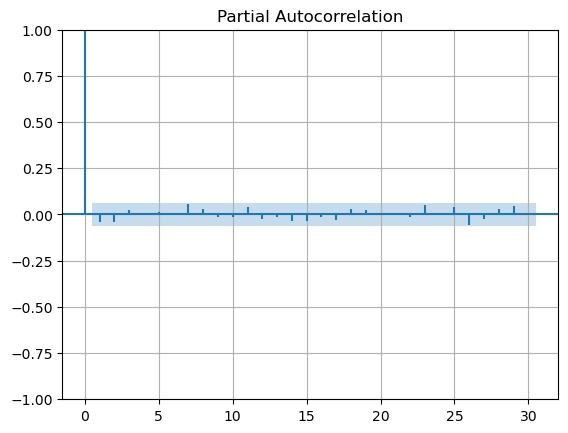

In [28]:
plot_pacf(model_mean.resid, marker='')
plt.grid()

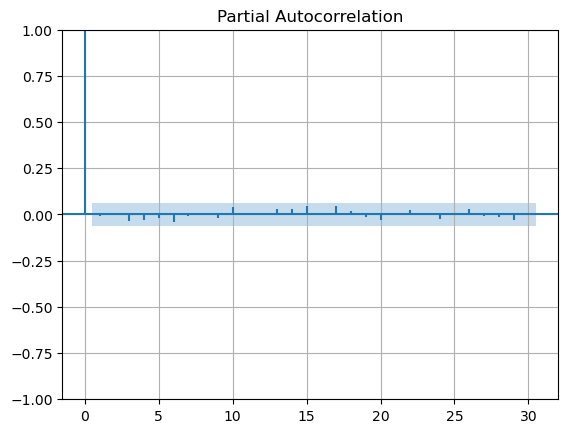

In [29]:
plot_pacf(model_mean.resid**2, marker='')
plt.grid()

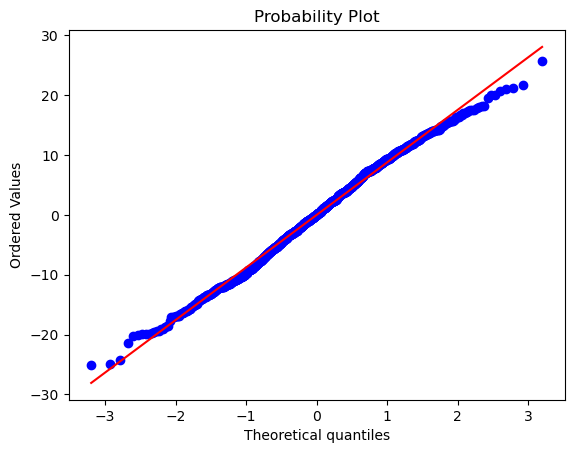

In [30]:
stats.probplot(model_mean.resid, dist='norm', plot=plt);

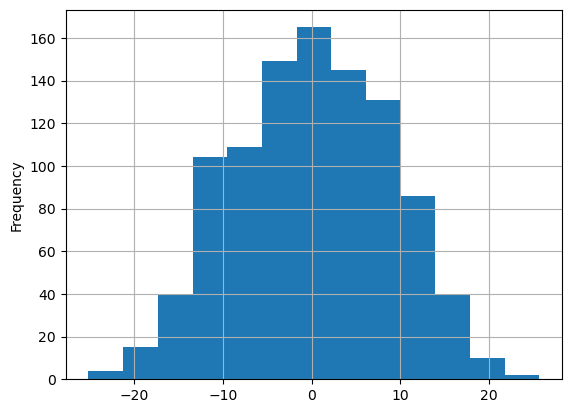

In [31]:
model_mean.resid.plot(kind='hist',bins=13,grid=True);

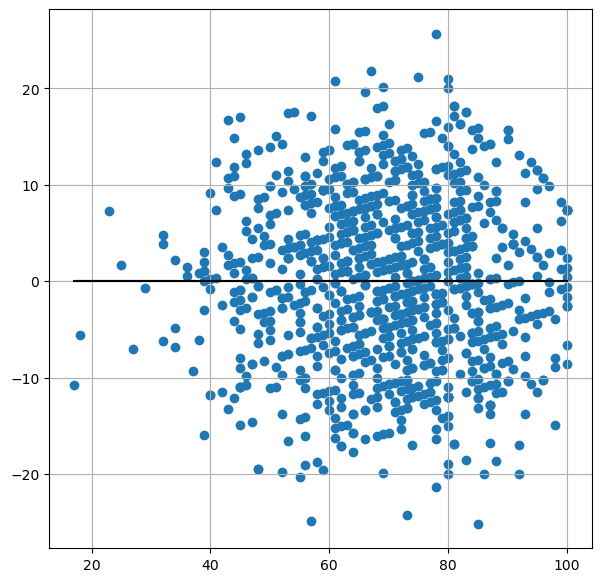

In [40]:
plt.figure(figsize=(7,7))
plt.scatter(x=data['Reading_Writing'],y=model_mean.resid)
m,c = np.polyfit(data['Reading_Writing'],model_mean.resid,1)

plt.plot(data['Reading_Writing'], m * data['Reading_Writing'] + c, color='black')
plt.grid()

plt.show()

In [32]:
stats.pearsonr(data['Reading_Writing'], model_mean.resid)

PearsonRResult(statistic=3.963843142607004e-16, pvalue=0.9999999999999895)

In [97]:
from statsmodels.multivariate.factor import Factor

language_data= data[['Reading' , 'Writing']]

factor= Factor(language_data,n_factor=1,method='pa').fit()

print(factor.summary())

Factor analysis results
    Eigenvalues        
------------------------------
        Reading        Writing
------------------------------
         1.9045        -0.0000
-----------------------
                       
-----------------------
    Communality        
------------------------------
        Reading        Writing
------------------------------
         0.9522         0.9522
-----------------------
                       
-----------------------
 Pre-rotated loadings  
-----------------------
               factor 0
-----------------------
Reading          0.9758
Writing          0.9758
-----------------------
                       



In [98]:
data['Language_Factor'] = factor.factor_scoring()

In [99]:
data

,Math,Reading,Writing,Reading_Writing,Language_Factor,Language_PC1
0,48,68,63,66.0,-0.254244,-0.007945
1,62,81,72,77.0,0.502784,0.015712
2,79,80,78,79.0,0.669537,0.020922
3,76,83,79,81.0,0.808031,0.025250
4,59,64,62,63.0,-0.427697,-0.013365
...,...,...,...,...,...,...
995,72,74,70,72.0,0.190837,0.005963
996,73,86,90,88.0,1.282711,0.040084
997,89,87,94,91.0,1.452143,0.045378
998,83,82,78,80.0,0.739454,0.023107


In [67]:
stats.pearsonr(data['Math'],data['Language_Factor'])

PearsonRResult(statistic=0.8135902820760494, pvalue=2.927491423202083e-237)

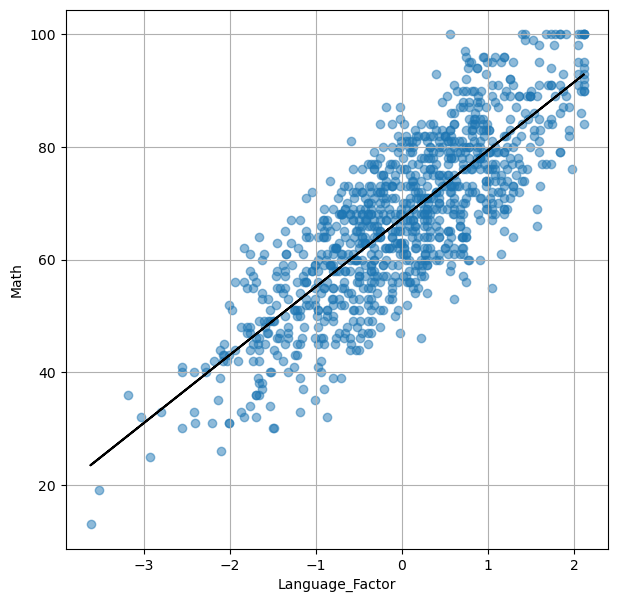

In [68]:
plt.figure(figsize=(7,7))

plt.scatter(data['Language_Factor'],data['Math'],alpha=0.5)

m ,c = np.polyfit(data['Language_Factor'],data['Math'],1)

plt.plot(data['Language_Factor'], m * data['Language_Factor'] + c ,color='black' )

plt.grid()

plt.xlabel('Language_Factor')
plt.ylabel('Math')
plt.show()

In [69]:
x2 = sm.add_constant(data['Language_Factor'])

model_factor = sm.OLS(y,x2).fit()

print(model_factor.summary())

                            OLS Regression Results                            
Dep. Variable:                   Math   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     1954.
Date:                Thu, 16 Jul 2026   Prob (F-statistic):          2.93e-237
Time:                        00:50:12   Log-Likelihood:                -3589.9
No. Observations:                1000   AIC:                             7184.
Df Residuals:                     998   BIC:                             7194.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              67.2900      0.278    2

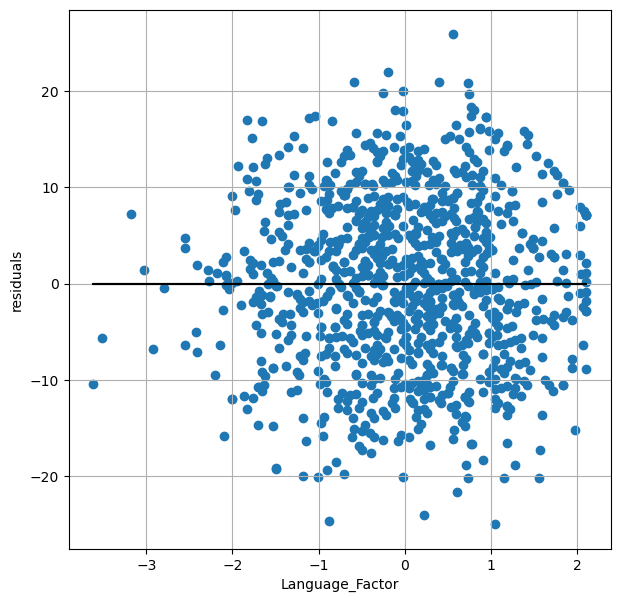

In [70]:
plt.figure(figsize=(7,7))
plt.scatter(x=data['Language_Factor'],y=model_factor.resid)

m ,c = np.polyfit(x=data['Language_Factor'],y=model_factor.resid,deg=1)

plt.plot(data['Language_Factor'],m * data['Language_Factor']+c ,color='black' )

plt.grid()
plt.xlabel('Language_Factor')
plt.ylabel('residuals')
plt.show()

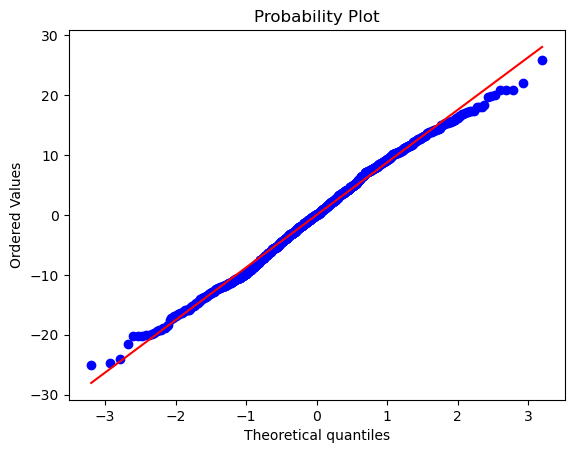

In [105]:
stats.probplot(model_factor.resid, dist='norm', plot=plt);

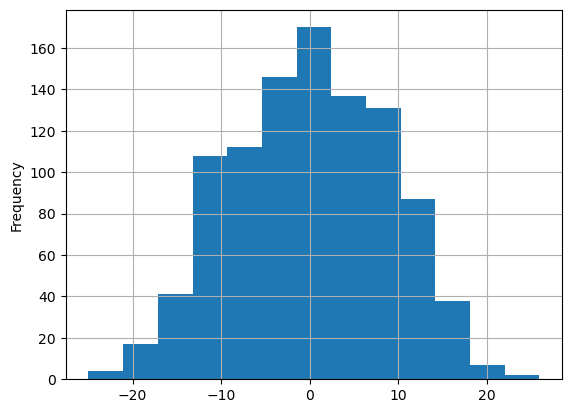

In [83]:
model_factor.resid.plot(kind='hist',bins=13,grid=True);

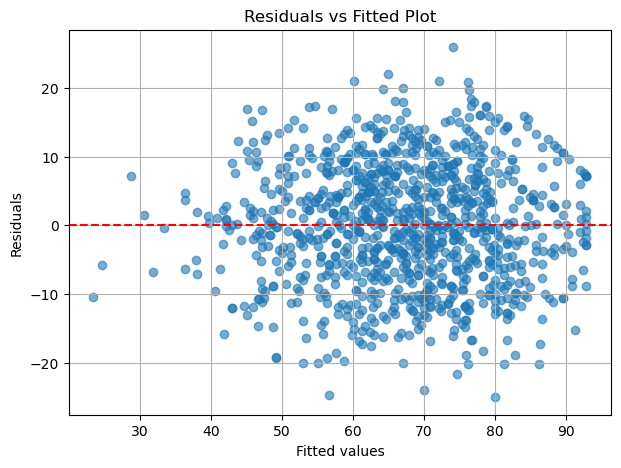

In [73]:
plt.figure(figsize=(7,5))
plt.scatter(model_factor.predict(x2),model_factor.resid,alpha=0.6)
plt.axhline(y=0, color='red',linestyle='--')
plt.title('Residuals vs Fitted Plot')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid()
plt.show()

In [78]:
het_white(model_factor.resid, model_factor.model.exog)

(6.00675537272366, 0.04961918695103825, 3.012462679689104, 0.04961823129323728)

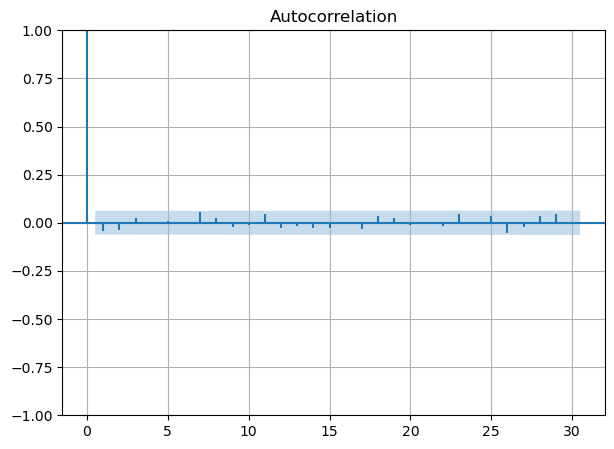

In [77]:
fig ,ax = plt.subplots(figsize=(7,5))

plot_acf(model_factor.resid,ax=ax,marker='');
plt.grid()

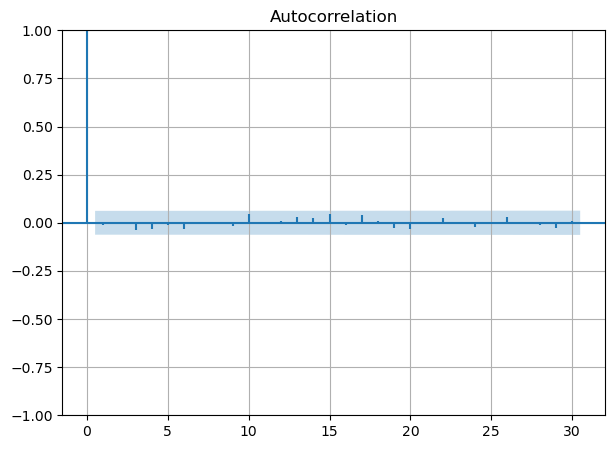

In [79]:
fig ,ax = plt.subplots(figsize=(7,5))

plot_acf(model_factor.resid**2,ax=ax,marker='');
plt.grid()

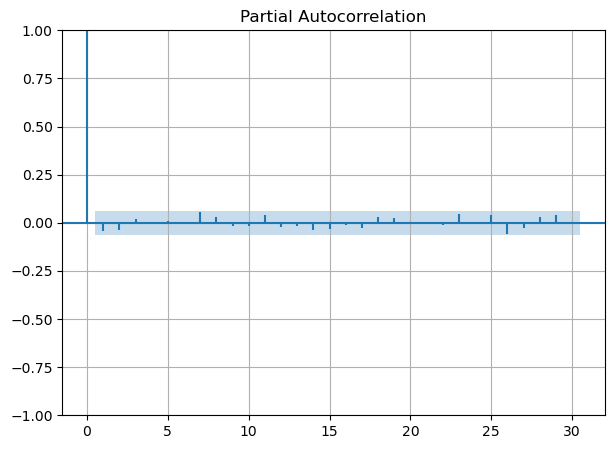

In [80]:
fig ,ax = plt.subplots(figsize=(7,5))

plot_pacf(model_factor.resid,ax=ax,marker='');
plt.grid()

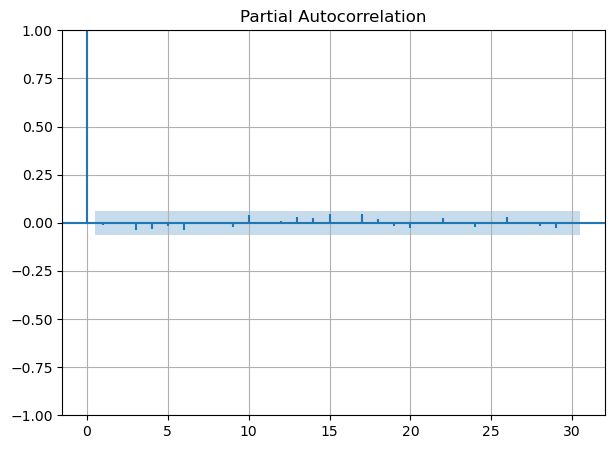

In [81]:
fig ,ax = plt.subplots(figsize=(7,5))

plot_pacf(model_factor.resid**2,ax=ax,marker='');
plt.grid()

In [85]:
from statsmodels.multivariate.pca import PCA

In [96]:
languag_data= data[['Reading','Writing']]

pca= PCA(languag_data, ncomp=1, demean=True, standardize=True)

data['Language_PC1'] = pca.scores['comp_0']

print("نسبة التباين المفسر الإجمالية")
print(pca.rsquare,'\n')

print("القيم الذاتية (Eigenvalues)")
print(pca.eigenvals,'\n')

print("أوزان المتغيرات (Loadings)")
print(pca.loadings)

نسبة التباين المفسر الإجمالية
ncomp
0    0.000000
1    0.976113
Name: rsquare, dtype: float64 

القيم الذاتية (Eigenvalues)
0    1952.225698
Name: eigenvals, dtype: float64 

أوزان المتغيرات (Loadings)
           comp_0
Reading  0.707107
Writing  0.707107


In [94]:
data

,Math,Reading,Writing,Reading_Writing,Language_Factor,Language_PC1
0,48,68,63,66.0,-0.254244,-0.007945
1,62,81,72,77.0,0.502784,0.015712
2,79,80,78,79.0,0.669537,0.020922
3,76,83,79,81.0,0.808031,0.025250
4,59,64,62,63.0,-0.427697,-0.013365
...,...,...,...,...,...,...
995,72,74,70,72.0,0.190837,0.005963
996,73,86,90,88.0,1.282711,0.040084
997,89,87,94,91.0,1.452143,0.045378
998,83,82,78,80.0,0.739454,0.023107


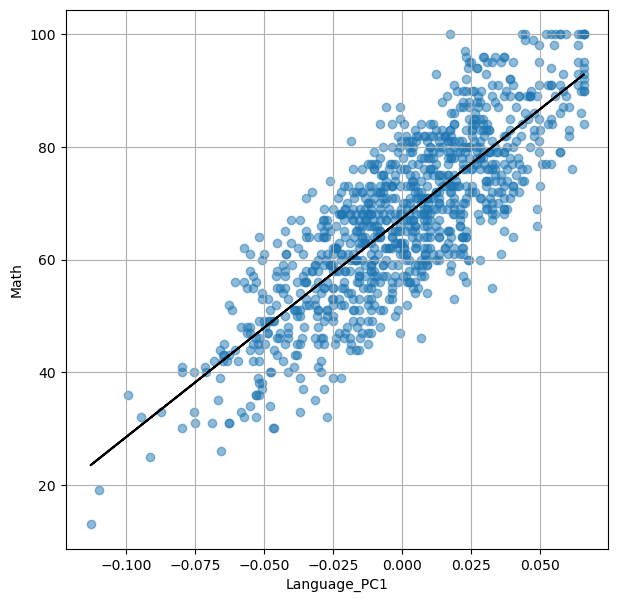

In [92]:
plt.figure(figsize=(7,7))
plt.scatter(data['Language_PC1'],data['Math'],alpha=0.5)

m, c = np.polyfit(data['Language_PC1'],data['Math'],1)
plt.plot(data['Language_PC1'], m * data['Language_PC1']+c,color='black')

plt.xlabel('Language_PC1')
plt.ylabel('Math')

plt.grid()
plt.show()

In [87]:
stats.pearsonr(data['Language_PC1'],data['Math'])

PearsonRResult(statistic=0.8135902820760492, pvalue=2.9274914232035384e-237)

In [101]:
x3 = sm.add_constant(data['Language_PC1'])

model_pca = sm.OLS(y,x3).fit()

print(model_pca.summary())

                            OLS Regression Results                            
Dep. Variable:                   Math   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     1954.
Date:                Thu, 16 Jul 2026   Prob (F-statistic):          2.93e-237
Time:                        01:20:17   Log-Likelihood:                -3589.9
No. Observations:                1000   AIC:                             7184.
Df Residuals:                     998   BIC:                             7194.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           67.2900      0.278    242.484   

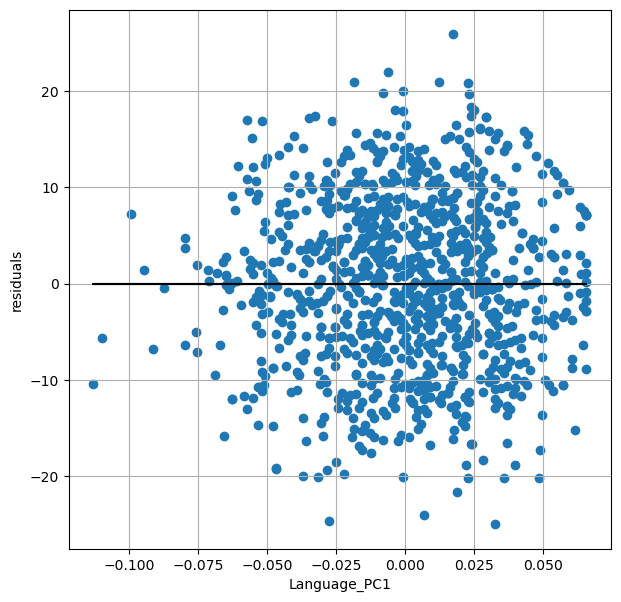

In [102]:
plt.figure(figsize=(7,7))
plt.scatter(x=data['Language_PC1'],y=model_pca.resid)

m ,c = np.polyfit(x=data['Language_PC1'],y=model_pca.resid,deg=1)

plt.plot(data['Language_PC1'],m * data['Language_PC1']+c ,color='black' )

plt.grid()
plt.xlabel('Language_PC1')
plt.ylabel('residuals')
plt.show()

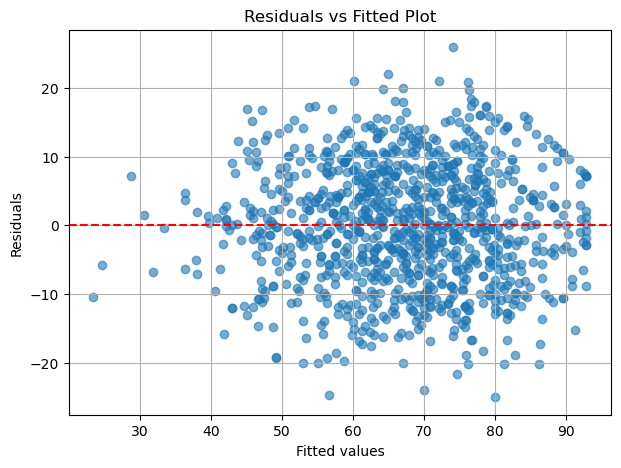

In [103]:
plt.figure(figsize=(7,5))
plt.scatter(model_pca.predict(x3),model_pca.resid,alpha=0.6)
plt.axhline(y=0, color='red',linestyle='--')
plt.title('Residuals vs Fitted Plot')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid()
plt.show()

In [104]:
het_white(model_pca.resid, model_pca.model.exog)

(6.006755372723438,
 0.04961918695104379,
 3.0124626796889986,
 0.04961823129324362)

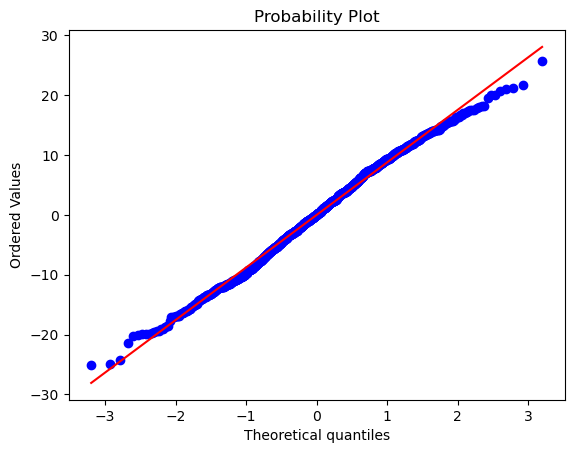

In [106]:
stats.probplot(model_mean.resid, dist='norm', plot=plt);

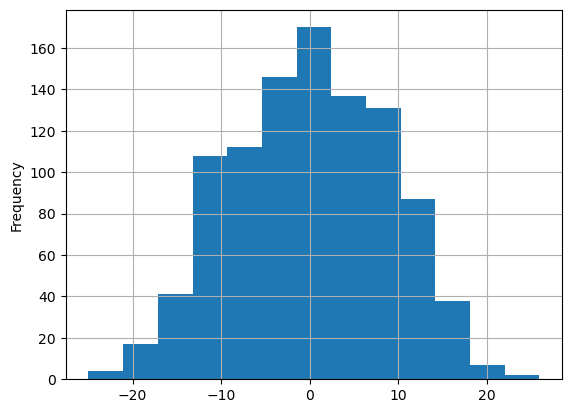

In [108]:
model_pca.resid.plot(kind='hist',bins=13,grid=True);

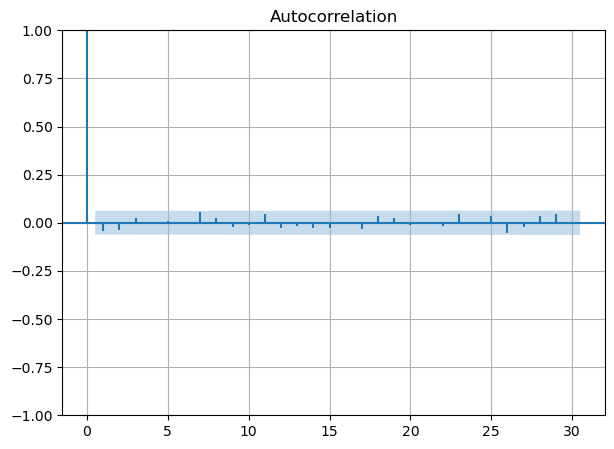

In [109]:
fig ,ax = plt.subplots(figsize=(7,5))

plot_acf(model_pca.resid,ax=ax,marker='');
plt.grid()

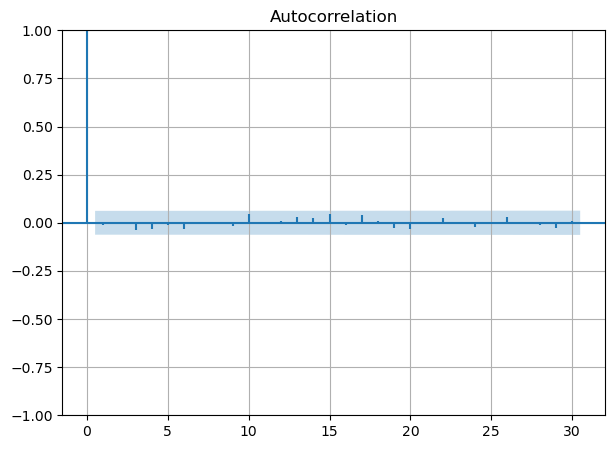

In [110]:
fig ,ax = plt.subplots(figsize=(7,5))

plot_acf(model_pca.resid**2,ax=ax,marker='');
plt.grid()

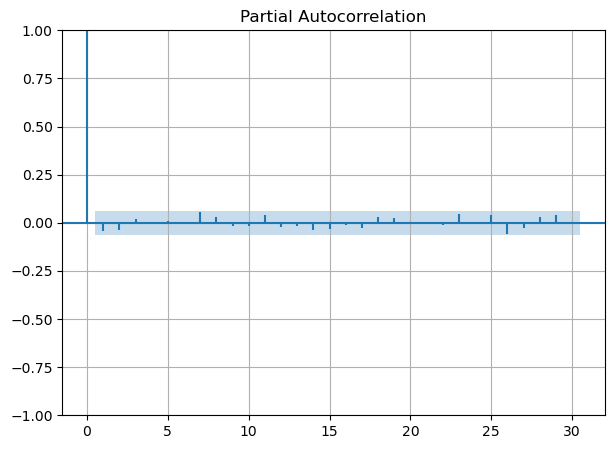

In [111]:
fig ,ax = plt.subplots(figsize=(7,5))

plot_pacf(model_pca.resid,ax=ax,marker='');
plt.grid()

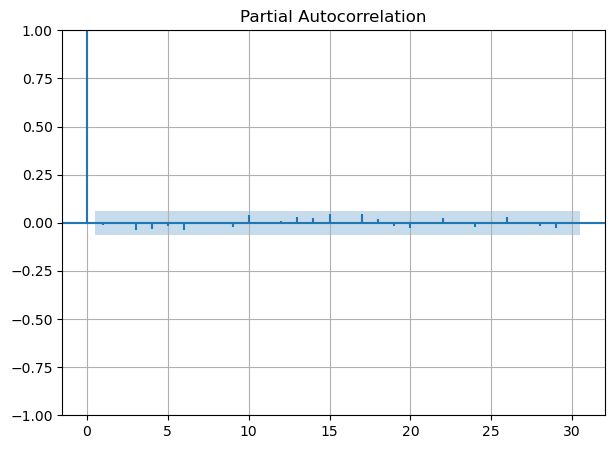

In [112]:
fig ,ax = plt.subplots(figsize=(7,5))

plot_pacf(model_pca.resid**2,ax=ax,marker='');
plt.grid()